# Kernel Methods with MerLin

This notebook illustrates how to build photonic feature maps and quantum kernels using MerLin.
We cover the quickstart factory, custom circuits, and how to plug the resulting Gram matrices
into classical machine-learning pipelines built around the Iris dataset.


## Setup

We standardise the Iris features, split train/test partitions, and rely on scikit-learn to
train classical models on the precomputed kernel matrices.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from merlin import ComputationSpace
from merlin.algorithms.kernels import FeatureMap, FidelityKernel, KernelCircuitBuilder

torch.manual_seed(0)
np.random.seed(0)

iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target

X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=12
)

X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)

## Fidelity kernel in a few lines

`FidelityKernel.simple` constructs a kernel-ready photonic circuit and feature map.
It encodes real inputs into a multi-mode Fock space, evaluates their overlaps, and
returns a positive-semidefinite Gram matrix.


In [2]:
kernel = FidelityKernel.simple(
    input_size=4,
    n_modes=6,  # Here the number of modes is optional, if n_modes is not given, n_modes=input_size+1
    shots=0,  # exact probabilities
    computation_space=ComputationSpace.FOCK,
    dtype=torch.float32,
    device=torch.device("cpu"),
)

K_train = kernel(X_train)
K_test = kernel(X_test, X_train)

print("Train Gram shape:", K_train.shape)
print("Test Gram shape:", K_test.shape)

Train Gram shape: torch.Size([105, 105])
Test Gram shape: torch.Size([45, 105])


### Use with scikit-learn

We can train any estimator that accepts precomputed kernels. Below we use an SVM
to distinguish the three Iris species from the quantum kernel features.


In [3]:
svc = SVC(kernel="precomputed")
svc.fit(K_train.detach().numpy(), y_train)
test_accuracy = svc.score(K_test.detach().numpy(), y_test)
print(f"SVM accuracy (precomputed kernel): {test_accuracy:.3f}")

SVM accuracy (precomputed kernel): 1.000


### Decision regions on a 2D Iris feature slice

The classifier is trained on the four standardized Iris features, so the true decision frontier
lives in four dimensions. To visualize a 2D slice, we vary petal length and petal width while
keeping the other standardized features fixed at zero.


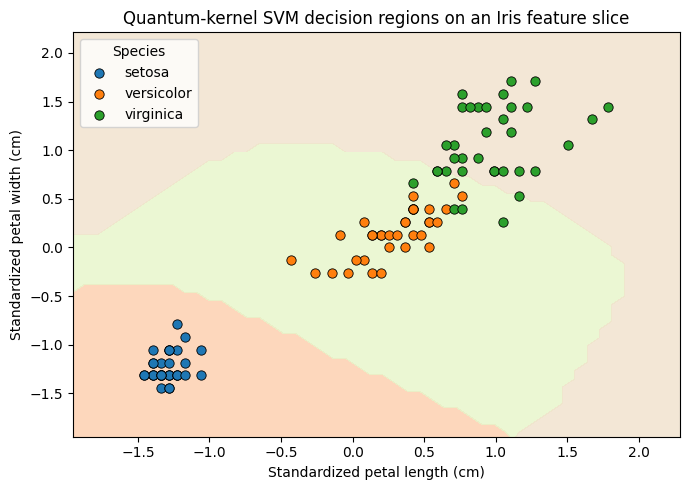

In [4]:
x_feature_index = 2
y_feature_index = 3
slice_mesh_resolution = 50

X_train_numpy = X_train.detach().numpy()
x_feature_min = X_train_numpy[:, x_feature_index].min() - 0.5
x_feature_max = X_train_numpy[:, x_feature_index].max() + 0.5
y_feature_min = X_train_numpy[:, y_feature_index].min() - 0.5
y_feature_max = X_train_numpy[:, y_feature_index].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_feature_min, x_feature_max, slice_mesh_resolution),
    np.linspace(y_feature_min, y_feature_max, slice_mesh_resolution),
)
grid_points = np.zeros((xx.size, X_train_numpy.shape[1]), dtype=np.float32)
grid_points[:, x_feature_index] = xx.ravel()
grid_points[:, y_feature_index] = yy.ravel()

with torch.no_grad():
    K_grid = kernel(torch.tensor(grid_points), X_train)

decision_regions = svc.predict(K_grid.detach().numpy()).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
region_levels = np.arange(len(iris.target_names) + 1) - 0.5
ax.contourf(xx, yy, decision_regions, levels=region_levels, cmap="Pastel2", alpha=0.8)

for class_id, species_name in enumerate(iris.target_names):
    class_mask = y_train == class_id
    ax.scatter(
        X_train_numpy[class_mask, x_feature_index],
        X_train_numpy[class_mask, y_feature_index],
        label=species_name,
        edgecolor="black",
        linewidth=0.6,
        s=45,
    )

ax.set_xlabel(f"Standardized {iris.feature_names[x_feature_index]}")
ax.set_ylabel(f"Standardized {iris.feature_names[y_feature_index]}")
ax.set_title("Quantum-kernel SVM decision regions on an Iris feature slice")
ax.legend(title="Species")
fig.tight_layout()

## Custom feature maps and experiments

For full control over the optical layout, detectors, and noise, build a `perceval.Circuit`
and wrap it with `FeatureMap`. Fidelity kernels then evaluate overlaps between the resulting states.


In [5]:
circuit = pcvl.Circuit(4)
circuit.add((0, 1), pcvl.BS())
circuit.add(0, pcvl.PS(pcvl.P("phi0")))
circuit.add(1, pcvl.PS(pcvl.P("phi1")))
circuit.add(2, pcvl.PS(pcvl.P("phi2")))
circuit.add(3, pcvl.PS(pcvl.P("phi3")))
circuit.add((2, 3), pcvl.BS())

experiment = pcvl.Experiment(circuit)
experiment.noise = pcvl.NoiseModel(brightness=0.93)

feature_map = FeatureMap(
    experiment=experiment,
    input_size=4,
    input_parameters="phi",
    dtype=torch.float32,
)

custom_kernel = FidelityKernel(
    feature_map=feature_map,
    input_state=[1, 0, 1, 0],
    computation_space=ComputationSpace.UNBUNCHED,
)

K_custom = custom_kernel(X_train[:20])
print("Custom kernel Gram shape:", K_custom.shape)

Custom kernel Gram shape: torch.Size([20, 20])


## Declarative kernel circuits

`KernelCircuitBuilder` offers a fluent API to assemble reusable feature maps programmatically.


In [6]:
builder = (
    KernelCircuitBuilder()
    .input_size(4)
    .n_modes(6)
    .n_photons(2)
    .angle_encoding(scale=0.7)
    .trainable(enabled=True, prefix="theta")
)

builder_kernel = builder.build_fidelity_kernel(
    input_state=[1, 1, 0, 0, 0, 0],
    shots=512,
    computation_space=ComputationSpace.FOCK,
)

K_builder = builder_kernel(X_train[:15])
print("Builder kernel Gram shape:", K_builder.shape)

Builder kernel Gram shape: torch.Size([15, 15])


## Conclusion

- Use `FidelityKernel.simple` for quick experiments where a default photonic layout suffices.
- Wrap custom `perceval.Experiment` objects with `FeatureMap` to reflect hardware noise and detector choices.
- `KernelCircuitBuilder` helps script repeatable feature maps with entangling blocks and measurement strategies.
- The resulting Gram matrices integrate with classical ML libraries by choosing the `precomputed` kernel option.
